## Ecesis Investments 2026 Summer Internship - Bus-Level Load Prediction Pipeline

Two forecasting tasks:
- **Task A**: Next-day forecast — predict all 24 hours of tomorrow for every bus
- **Task B**: Next-month forecast — predict all hours of next month for every bus

Test period: full calendar year 2025. Train: 2022–2024.

## 0. Setup

In [1]:
import glob
import os
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 100

print("pandas", pd.__version__)
print("lightgbm", lgb.__version__)

pandas 3.0.3
lightgbm 4.6.0


## 1. Data Loading & Exploration

In [2]:
def load_bus(years=range(2022, 2026)):
    """Load bus data, keep LOAD buses with non-null pd only."""
    parts = []
    for yr in years:
        df = pd.read_parquet(f"raw_data/bus_load_{yr}.parquet")
        df = df[df["bus_type"] == "LOAD"].dropna(subset=["pd"])
        parts.append(df)
        print(f"  {yr}: {len(df):,} rows, {df['bus_unique_id'].nunique():,} buses")
    return pd.concat(parts, ignore_index=True)


def load_zone(years=range(2022, 2026)):
    parts = []
    for yr in years:
        df = pd.read_parquet(f"raw_data/zone_load_{yr}.parquet")
        parts.append(df)
    return pd.concat(parts, ignore_index=True)


print("Loading bus data...")
bus = load_bus()
print(f"Total bus rows: {len(bus):,}")

print("\nLoading zone data...")
zone = load_zone()
print(f"Total zone rows: {len(zone):,}")

Loading bus data...
  2022: 33,297,510 rows, 4,684 buses
  2023: 33,250,267 rows, 4,705 buses
  2024: 33,414,019 rows, 4,751 buses
  2025: 33,447,112 rows, 4,793 buses
Total bus rows: 133,408,908

Loading zone data...
Total zone rows: 315,153


In [3]:
# Add datetime column (he is Hour Ending 1-24; subtract 1 for hour-start offset)
bus["datetime"] = pd.to_datetime(bus["date"]) + pd.to_timedelta(bus["he"] - 1, unit="h")
zone["datetime"] = pd.to_datetime(zone["date"]) + pd.to_timedelta(zone["he"] - 1, unit="h")

bus = bus.sort_values(["bus_unique_id", "datetime"]).reset_index(drop=True)
zone = zone.sort_values(["zone_name", "datetime"]).reset_index(drop=True)

print("Bus date range:", bus["date"].min(), "to", bus["date"].max())
print("Zone date range:", zone["date"].min(), "to", zone["date"].max())
print("\nBus summary:")
print(bus[["pd", "base_kv"]].describe().round(2))
print("\nZones:", sorted(bus["zone_name"].unique()))

Bus date range: 2022-01-01 to 2025-12-31
Zone date range: 2022-01-01 to 2025-12-31

Bus summary:
                 pd       base_kv
count  1.334089e+08  1.334089e+08
mean   1.331000e+01  1.201100e+02
std    2.236000e+01  3.661000e+01
min    0.000000e+00  4.160000e+00
25%    2.200000e+00  6.900000e+01
50%    7.470000e+00  1.380000e+02
75%    1.705000e+01  1.380000e+02
max    1.629140e+03  3.450000e+02

Zones: ['COAS', 'EAST', 'FWES', 'NCEN', 'NOTH', 'SCEN', 'SOUT', 'WEST']


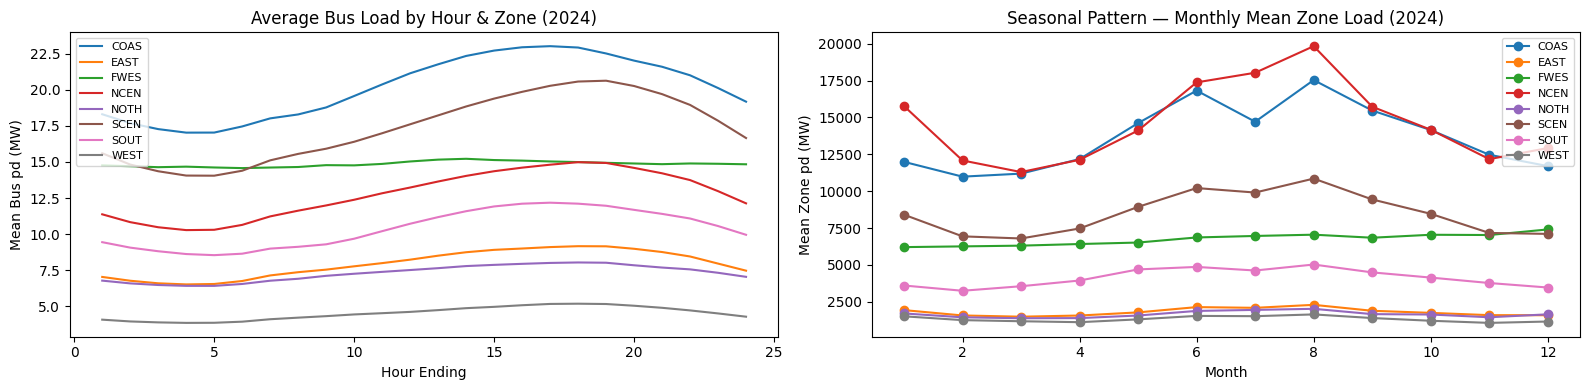

In [4]:
# EDA Plot 1: average hourly load by zone (2024)
sample = bus[bus["date"].between("2024-01-01", "2024-12-31")]
zone_hourly = sample.groupby(["zone_name", "he"])["pd"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for zone_name, grp in zone_hourly.groupby("zone_name"):
    if zone_name == "ISOLATED":
        continue
    axes[0].plot(grp["he"], grp["pd"], label=zone_name)
axes[0].set_title("Average Bus Load by Hour & Zone (2024)")
axes[0].set_xlabel("Hour Ending")
axes[0].set_ylabel("Mean Bus pd (MW)")
axes[0].legend(fontsize=8)

# EDA Plot 2: seasonal pattern — monthly average total zone load
zone24 = zone[zone["date"].between("2024-01-01", "2024-12-31")].copy()
zone24["month"] = pd.to_datetime(zone24["date"]).dt.month
zone24_monthly = zone24[zone24["zone_name"] != "ISOLATED"].groupby(["zone_name", "month"])["pd"].mean().reset_index()

for zone_name, grp in zone24_monthly.groupby("zone_name"):
    axes[1].plot(grp["month"], grp["pd"], marker="o", label=zone_name)
axes[1].set_title("Seasonal Pattern — Monthly Mean Zone Load (2024)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean Zone pd (MW)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("outputs/eda_load_patterns.png", bbox_inches="tight")
plt.show()

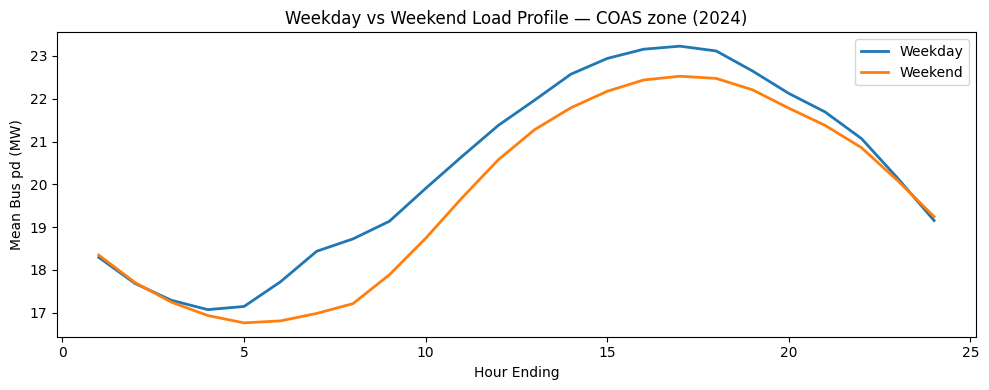

In [5]:
# EDA Plot 3: weekday vs weekend pattern for a single zone
sample_coas = sample[sample["zone_name"] == "COAS"].copy()
sample_coas["weekday"] = pd.to_datetime(sample_coas["date"]).dt.dayofweek
sample_coas["is_weekend"] = sample_coas["weekday"].isin([5, 6])

wd_pattern = sample_coas.groupby(["is_weekend", "he"])["pd"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
for is_wknd, grp in wd_pattern.groupby("is_weekend"):
    label = "Weekend" if is_wknd else "Weekday"
    ax.plot(grp["he"], grp["pd"], label=label, linewidth=2)
ax.set_title("Weekday vs Weekend Load Profile — COAS zone (2024)")
ax.set_xlabel("Hour Ending")
ax.set_ylabel("Mean Bus pd (MW)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/eda_weekday_weekend.png", bbox_inches="tight")
plt.show()

## 2. Feature Engineering

Two feature sets:
- **Task A features**: include `lag_24` and `lag_168` — valid because the previous day and previous week are known at forecast time for next-day prediction
- **Task B features**: use `lag_8736` (same hour 364 days ago = same weekday, prior year) and historical mean — `lag_24`/`lag_168` would require values mid-month that aren't known at month-start forecast time

In [ ]:
def add_calendar_features(df):
    dt = pd.to_datetime(df["date"])
    df = df.copy()
    df["weekday"] = dt.dt.dayofweek       # 0=Mon, 6=Sun
    df["month"] = dt.dt.month
    df["weekend_flag"] = dt.dt.dayofweek.isin([5, 6]).astype("int8")
    return df


def add_lag_features_task_a(df):
    """Lag features for next-day forecast — lag_24 and lag_168 are leak-free."""
    df = df.copy()
    grp = df.groupby("bus_unique_id")["pd"]
    df["lag_24"] = grp.shift(24)
    df["lag_168"] = grp.shift(168)
    df["rolling_mean_24"] = grp.transform(lambda x: x.shift(1).rolling(24, min_periods=1).mean())
    df["rolling_mean_168"] = grp.transform(lambda x: x.shift(1).rolling(168, min_periods=1).mean())
    return df


def add_lag_features_task_b(df):
    """Lag features for next-month forecast — only year-ago lag is safe."""
    df = df.copy()
    grp = df.groupby("bus_unique_id")["pd"]
    # 364 days = 52 weeks = same weekday alignment, 1 year prior
    df["lag_8736"] = grp.shift(364 * 24)
    df["rolling_mean_7d"] = grp.transform(lambda x: x.shift(1).rolling(168, min_periods=24).mean())
    return df


FEATURES_A = ["he", "weekday", "month", "weekend_flag", "base_kv",
              "lag_24", "lag_168", "rolling_mean_24", "rolling_mean_168"]

FEATURES_B = ["he", "weekday", "month", "weekend_flag", "base_kv",
              "lag_8736", "rolling_mean_7d", "hist_mean"]

print("Feature sets defined.")
print("Task A:", FEATURES_A)
print("Task B:", FEATURES_B)

Feature sets defined.
Task A: ['he', 'weekday', 'month', 'weekend_flag', 'base_kv', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168']
Task B: ['he', 'weekday', 'month', 'weekend_flag', 'base_kv', 'lag_8736', 'rolling_mean_7d', 'hist_mean']


: 

In [ ]:
print("Adding calendar features...")
bus = add_calendar_features(bus)

print("Adding Task A lag features (lag_24, lag_168)...")
bus = add_lag_features_task_a(bus)

print("Adding Task B lag features (lag_8736)...")
bus = add_lag_features_task_b(bus)

print(f"DataFrame shape after feature engineering: {bus.shape}")
print(bus[["bus_unique_id", "date", "he", "pd", "lag_24", "lag_168", "lag_8736"]].head(3))

Adding calendar features...


## 3. Train / Validation / Test Split

In [ ]:
TRAIN_END = "2023-12-31"
VAL_START = "2024-01-01"
VAL_END   = "2024-12-31"
TEST_START = "2025-01-01"
TEST_END   = "2025-12-31"

train = bus[bus["date"] <= TRAIN_END].copy()
val   = bus[bus["date"].between(VAL_START, VAL_END)].copy()
test  = bus[bus["date"].between(TEST_START, TEST_END)].copy()

print(f"Train: {len(train):,} rows ({train['date'].min()} → {train['date'].max()})")
print(f"Val:   {len(val):,} rows ({val['date'].min()} → {val['date'].max()})")
print(f"Test:  {len(test):,} rows ({test['date'].min()} → {test['date'].max()})")

## 4. Baseline Models

In [ ]:
def wmape(actual, pred):
    mask = actual > 0
    return np.sum(np.abs(actual[mask] - pred[mask])) / np.sum(actual[mask])


def evaluate(actual, pred, label=""):
    actual, pred = np.array(actual), np.array(pred)
    mask = ~(np.isnan(actual) | np.isnan(pred))
    a, p = actual[mask], pred[mask]
    mae  = mean_absolute_error(a, p)
    rmse = mean_squared_error(a, p) ** 0.5
    wm   = wmape(a, p)
    print(f"{label:30s}  MAE={mae:.3f}  RMSE={rmse:.3f}  WMAPE={wm:.4f}")
    return {"mae": mae, "rmse": rmse, "wmape": wm}


# Baseline 1: previous week same hour (lag_168)
evaluate(val["pd"], val["lag_168"], "Baseline: prev-week same hour")

# Baseline 2: historical average by (bus, he, weekday) from train set
hist_avg = (
    train.groupby(["bus_unique_id", "he", "weekday"])["pd"]
    .mean()
    .rename("hist_mean")
    .reset_index()
)
val = val.merge(hist_avg, on=["bus_unique_id", "he", "weekday"], how="left")
test = test.merge(hist_avg, on=["bus_unique_id", "he", "weekday"], how="left")
train = train.merge(hist_avg, on=["bus_unique_id", "he", "weekday"], how="left")

evaluate(val["pd"], val["hist_mean"], "Baseline: hist avg (bus, he, wday)")

## 5. LightGBM Model — Task A (Next-Day)

In [ ]:
# Drop rows where any Task A feature is null (first 168 hours per bus)
train_a = train.dropna(subset=FEATURES_A + ["pd"]).copy()
val_a   = val.dropna(subset=FEATURES_A + ["pd"]).copy()

X_train_a = train_a[FEATURES_A]
y_train_a = train_a["pd"]
X_val_a   = val_a[FEATURES_A]
y_val_a   = val_a["pd"]

print(f"Train A: {len(X_train_a):,} rows")
print(f"Val A:   {len(X_val_a):,} rows")

In [ ]:
model_a = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
)

model_a.fit(
    X_train_a, y_train_a,
    eval_set=[(X_val_a, y_val_a)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

val_pred_a = model_a.predict(X_val_a)
val_pred_a = np.maximum(val_pred_a, 0)  # load cannot be negative

print("\n=== Task A — Validation Results ===")
evaluate(val["pd"], val["lag_168"], "Baseline: prev-week same hour")
evaluate(val["pd"], val["hist_mean"], "Baseline: hist avg")
evaluate(y_val_a, val_pred_a, "LightGBM Task A")

In [ ]:
# Feature importance
fi = pd.Series(model_a.feature_importances_, index=FEATURES_A).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
fi.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("LightGBM Feature Importance — Task A")
ax.set_xlabel("Importance (split count)")
plt.tight_layout()
plt.savefig("outputs/feature_importance_task_a.png", bbox_inches="tight")
plt.show()

## 6. LightGBM Model — Task B (Next-Month)

For next-month forecasting, `lag_24` and `lag_168` are not available at the forecast date (they would require values mid-month). Instead we use `lag_8736` (same hour 364 days ago = same weekday alignment, 1 year prior) and the historical mean from training data.

In [ ]:
train_b = train.dropna(subset=FEATURES_B + ["pd"]).copy()
val_b   = val.dropna(subset=FEATURES_B + ["pd"]).copy()

X_train_b = train_b[FEATURES_B]
y_train_b = train_b["pd"]
X_val_b   = val_b[FEATURES_B]
y_val_b   = val_b["pd"]

print(f"Train B: {len(X_train_b):,} rows")
print(f"Val B:   {len(X_val_b):,} rows")

In [ ]:
model_b = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
)

model_b.fit(
    X_train_b, y_train_b,
    eval_set=[(X_val_b, y_val_b)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

val_pred_b = model_b.predict(X_val_b)
val_pred_b = np.maximum(val_pred_b, 0)

print("\n=== Task B — Validation Results ===")
evaluate(val["pd"], val["hist_mean"], "Baseline: hist avg")
evaluate(y_val_b, val_pred_b, "LightGBM Task B")

In [ ]:
# Feature importance Task B
fi_b = pd.Series(model_b.feature_importances_, index=FEATURES_B).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
fi_b.plot(kind="barh", ax=ax, color="coral")
ax.set_title("LightGBM Feature Importance — Task B")
ax.set_xlabel("Importance (split count)")
plt.tight_layout()
plt.savefig("outputs/feature_importance_task_b.png", bbox_inches="tight")
plt.show()

## 7. Task A — Generate 2025 Next-Day Forecasts

The model is trained on 2022–2023. We predict all of 2025 in one pass. Lag features for 2025-01-01 draw from 2024 actuals — no leakage.

`forecast_created_at` = `target_date - 1 day` (i.e., "on day D, predict day D+1")

In [ ]:
test_a = test.dropna(subset=FEATURES_A).copy()

test_a["predict_pd"] = np.maximum(model_a.predict(test_a[FEATURES_A]), 0)

# forecast_created_at = the previous day at 00:01
test_a["target_date"] = test_a["date"]
test_a["forecast_created_at"] = (
    pd.to_datetime(test_a["date"]) - pd.Timedelta(days=1)
).dt.strftime("%Y-%m-%d") + " 00:01:00"

out_a = test_a[["forecast_created_at", "target_date", "he",
                "bus_unique_id", "zone_name", "predict_pd"]].copy()
out_a.insert(0, "model_name", "lgbm_direct_task_a")
out_a = out_a.rename(columns={"bus_unique_id": "bus_id", "zone_name": "zone_id"})

print(f"Task A output shape: {out_a.shape}")
print(out_a.head(3).to_string())

## 8. Task B — Generate 2025 Next-Month Forecasts

12 monthly forecasts. For each month M in 2025:
- `forecast_created_at` = 1st of month M−1
- `target` = all hours in month M

Only features available on or before `forecast_created_at` are used (`lag_8736`, `hist_mean`, calendar features).

In [ ]:
# forecast_created_at mapping: target month → forecast date
# Jan 2025 → Dec 1, 2024 | Feb → Jan 1, 2025 | ... | Dec → Nov 1, 2025
month_to_forecast_date = {
    1:  "2024-12-01",
    2:  "2025-01-01",
    3:  "2025-02-01",
    4:  "2025-03-01",
    5:  "2025-04-01",
    6:  "2025-05-01",
    7:  "2025-06-01",
    8:  "2025-07-01",
    9:  "2025-08-01",
    10: "2025-09-01",
    11: "2025-10-01",
    12: "2025-11-01",
}

test_b = test.dropna(subset=FEATURES_B).copy()
test_b["predict_pd"] = np.maximum(model_b.predict(test_b[FEATURES_B]), 0)
test_b["target_date"] = test_b["date"]
test_b["forecast_created_at"] = test_b["month"].map(month_to_forecast_date) + " 00:01:00"

out_b = test_b[["forecast_created_at", "target_date", "he",
                "bus_unique_id", "zone_name", "predict_pd"]].copy()
out_b.insert(0, "model_name", "lgbm_direct_task_b")
out_b = out_b.rename(columns={"bus_unique_id": "bus_id", "zone_name": "zone_id"})

print(f"Task B output shape: {out_b.shape}")
print(out_b.head(3).to_string())

## 9. Strategy B: Zone Forecast + Bus Share

An alternative strategy: predict total zone load, then distribute to buses using historical bus share within each zone. Zone totals are smoother and easier to forecast accurately.

In [ ]:
# Compute historical bus share: avg(bus pd) / avg(zone pd) by (bus, zone, he, weekday)
bus_avg = (
    train.groupby(["bus_unique_id", "zone_name", "he", "weekday"])["pd"]
    .mean()
    .rename("bus_avg")
    .reset_index()
)

zone_train = zone[zone["date"] <= TRAIN_END].copy()
zone_train["weekday"] = pd.to_datetime(zone_train["date"]).dt.dayofweek
zone_avg = (
    zone_train.groupby(["zone_name", "he", "weekday"])["pd"]
    .mean()
    .rename("zone_avg")
    .reset_index()
)

bus_share = bus_avg.merge(zone_avg, on=["zone_name", "he", "weekday"])
bus_share["share"] = bus_share["bus_avg"] / bus_share["zone_avg"].replace(0, np.nan)
bus_share = bus_share[["bus_unique_id", "zone_name", "he", "weekday", "share"]]

print(f"Bus share table: {len(bus_share):,} rows")
print(bus_share.head(3))

In [ ]:
# Train a zone-level LightGBM model (much smaller dataset)
zone_feats = ["he", "weekday", "month", "weekend_flag", "lag_168_zone", "rolling_mean_168_zone"]

def prepare_zone_df(zone_df):
    z = zone_df[zone_df["zone_name"] != "ISOLATED"].copy()
    z["weekday"] = pd.to_datetime(z["date"]).dt.dayofweek
    z["month"] = pd.to_datetime(z["date"]).dt.month
    z["weekend_flag"] = z["weekday"].isin([5, 6]).astype("int8")
    z = z.sort_values(["zone_name", "datetime"]).reset_index(drop=True)
    grp = z.groupby("zone_name")["pd"]
    z["lag_168_zone"] = grp.shift(168)
    z["rolling_mean_168_zone"] = grp.transform(lambda x: x.shift(1).rolling(168, min_periods=1).mean())
    return z

zone_all = prepare_zone_df(zone)
zone_train_df = zone_all[zone_all["date"] <= TRAIN_END].dropna(subset=zone_feats + ["pd"])
zone_val_df   = zone_all[zone_all["date"].between(VAL_START, VAL_END)].dropna(subset=zone_feats + ["pd"])
zone_test_df  = zone_all[zone_all["date"].between(TEST_START, TEST_END)].dropna(subset=zone_feats + ["pd"])

zone_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=63, n_jobs=-1, random_state=42)
zone_model.fit(
    zone_train_df[zone_feats], zone_train_df["pd"],
    eval_set=[(zone_val_df[zone_feats], zone_val_df["pd"])],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

zone_val_pred = np.maximum(zone_model.predict(zone_val_df[zone_feats]), 0)
print("\n=== Zone-level model validation ===")
evaluate(zone_val_df["pd"].values, zone_val_pred, "Zone LightGBM")

In [ ]:
# Apply zone forecast to test period, then distribute to buses via historical share
zone_test_df = zone_test_df.copy()
zone_test_df["zone_pred"] = np.maximum(zone_model.predict(zone_test_df[zone_feats]), 0)

# Merge zone predictions into test bus data
test_zone = test.merge(
    zone_test_df[["zone_name", "date", "he", "zone_pred"]],
    on=["zone_name", "date", "he"],
    how="left"
)
test_zone = test_zone.merge(bus_share, on=["bus_unique_id", "zone_name", "he", "weekday"], how="left")
test_zone["predict_pd_zone"] = np.maximum(test_zone["zone_pred"] * test_zone["share"], 0)

# Compare strategies on validation set
zone_val_preds_df = zone_val_df[["zone_name", "date", "he"]].copy()
zone_val_preds_df["zone_pred"] = zone_val_pred

val_zone = val.merge(zone_val_preds_df, on=["zone_name", "date", "he"], how="left")
val_zone = val_zone.merge(bus_share, on=["bus_unique_id", "zone_name", "he", "weekday"], how="left")
val_zone["predict_pd_zone"] = np.maximum(val_zone["zone_pred"] * val_zone["share"], 0)

print("
=== Strategy Comparison (Validation 2024) ===")
evaluate(val["pd"], val["lag_168"], "Baseline: prev-week")
evaluate(val_a["pd"], val_pred_a, "LightGBM Direct (Task A features)")
evaluate(
    val_zone.dropna(subset=["predict_pd_zone"])["pd"],
    val_zone.dropna(subset=["predict_pd_zone"])["predict_pd_zone"],
    "Zone + Bus Share"
)

## 10. Evaluation — Full 2025 Test Period

Evaluate at bus level and zone level (aggregate bus predictions to zone, compare against actual zone totals).

In [ ]:
# Bus-level evaluation on 2025 test set
print("=== Bus-Level Evaluation — 2025 Test Set ===")
evaluate(test_a["pd"], test_a["predict_pd"], "Task A — LightGBM Direct")
evaluate(test_b["pd"], test_b["predict_pd"], "Task B — LightGBM (month features)")

In [ ]:
# Zone-level evaluation: aggregate bus predictions to zone, compare to actual zone totals
def zone_aggregate_eval(bus_pred_df, actual_zone_df, pred_col="predict_pd", label=""):
    zone_pred_agg = (
        bus_pred_df.groupby(["zone_name", "date", "he"])[pred_col].sum().reset_index()
    )
    merged = zone_pred_agg.merge(
        actual_zone_df[["zone_name", "date", "he", "pd"]],
        on=["zone_name", "date", "he"]
    )
    evaluate(merged["pd"], merged[pred_col], f"Zone agg: {label}")

zone_test_actual = zone[zone["date"].between(TEST_START, TEST_END)]

print("=== Zone-Level Aggregated Evaluation — 2025 Test Set ===")
zone_aggregate_eval(
    test_a[["zone_name", "date", "he", "predict_pd"]],
    zone_test_actual,
    label="Task A Direct"
)
zone_aggregate_eval(
    test_b[["zone_name", "date", "he", "predict_pd"]],
    zone_test_actual,
    label="Task B Direct"
)

In [ ]:
# Spot-check: plot one bus's 2025 forecast vs actuals
sample_bus = test_a["bus_id"].iloc[0] if "bus_id" in test_a.columns else test_a["bus_unique_id"].iloc[0]
col = "bus_id" if "bus_id" in test_a.columns else "bus_unique_id"
spot = test_a[test_a[col] == sample_bus].head(24 * 14)  # 2 weeks

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spot["datetime"].values, spot["pd"].values, label="Actual", alpha=0.8)
ax.plot(spot["datetime"].values, spot["predict_pd"].values, label="Predicted", alpha=0.8, linestyle="--")
ax.set_title(f"Task A Spot Check — Bus: {sample_bus} (first 2 weeks of 2025)")
ax.set_xlabel("Datetime")
ax.set_ylabel("Load pd (MW)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/spot_check_task_a.png", bbox_inches="tight")
plt.show()

## 11. Save Output Files

In [ ]:
# Save Task A forecast
out_a.to_csv("outputs/task_a_nextday_forecast.csv", index=False)
print(f"Task A saved: outputs/task_a_nextday_forecast.csv  ({len(out_a):,} rows)")
print(out_a.dtypes)
print(out_a.head(2))

In [ ]:
# Save Task B forecast
out_b.to_csv("outputs/task_b_nextmonth_forecast.csv", index=False)
print(f"Task B saved: outputs/task_b_nextmonth_forecast.csv  ({len(out_b):,} rows)")
print(out_b.head(2))

In [ ]:
# Verify output schema matches required format
REQUIRED_COLS = ["model_name", "forecast_created_at", "target_date", "he", "bus_id", "zone_id", "predict_pd"]
assert list(out_a.columns) == REQUIRED_COLS, f"Schema mismatch Task A: {list(out_a.columns)}"
assert list(out_b.columns) == REQUIRED_COLS, f"Schema mismatch Task B: {list(out_b.columns)}"
assert (out_a["predict_pd"] >= 0).all(), "Negative predictions in Task A"
assert (out_b["predict_pd"] >= 0).all(), "Negative predictions in Task B"
print("Schema verification passed.")
print(f"Task A rows: {len(out_a):,}")
print(f"Task B rows: {len(out_b):,}")